## Sesotho Medical Machine Translation
### Data Analysis, Model Evaluation & Error Analysis

### Notebook Structure

    Content 

 Environment setup 

 Corpus overview and domain distribution

 Model architecture and design decisions 

 Automatic evaluation — BLEU, chrF++, TER 

 Metric visualisation 

 Qualitative error analysis (10 real examples) 
 
 Summary and conclusions 


### CELL 2 — Code: Install Packages

In [1]:
import subprocess
import sys

# Install all required packages
packages = [
    'pandas',
    'matplotlib',
    'seaborn',
    'sacrebleu',
    'sentencepiece'
]

for pkg in packages:
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        pkg,
        '-q'
    ])

print('All packages installed.')


All packages installed.


### CELL 3 — Code: Imports and File Paths

In [2]:
import os
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sacrebleu

warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# File paths 
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

CORPUS_PATH = os.path.join(
    ROOT,
    'backend',
    'data',
    'medical_corpus.csv'
)

EVAL_PATH = os.path.join(
    ROOT,
    'backend',
    'data',
    'evaluation_examples.csv'
)

RESULTS_PATH = os.path.join(
    ROOT,
    'backend',
    'data',
    'evaluation_results.txt'
)

print(f'Corpus  : {CORPUS_PATH}')
print(f'Eval    : {EVAL_PATH}')
print(f'Results : {RESULTS_PATH}')


Corpus  : c:\sesotho-medical-mt\backend\data\medical_corpus.csv
Eval    : c:\sesotho-medical-mt\backend\data\evaluation_examples.csv
Results : c:\sesotho-medical-mt\backend\data\evaluation_results.txt


### CELL 4 — Markdown: Section 1

### Section 1 — Corpus Overview

The project collected 4,200 English–Sesotho medical sentence pairs across 7 healthcare domains. Of these, 100 pairs were selected as an initial human-verified held-out evaluation set. The remaining pairs form a working prototype corpus for lookup, experimentation, and future human review.

### CELL 5 — Code: Load Corpus

In [3]:
corpus = pd.read_csv(CORPUS_PATH)

print(f'Total pairs  : {len(corpus):,}')
print(f'Columns      : {list(corpus.columns)}')
print(f'Missing vals :\n{corpus.isnull().sum().to_string()}')
print()

corpus.head()

Total pairs  : 5,000
Columns      : ['sentence_id', 'domain_category', 'english_text', 'sesotho_text', 'source', 'source_reference', 'translator_code', 'reviewer_status', 'notes']
Missing vals :
sentence_id            0
domain_category        0
english_text           0
sesotho_text           0
source                 0
source_reference       0
translator_code     5000
reviewer_status        0
notes               5000



,sentence_id,domain_category,english_text,sesotho_text,source,source_reference,translator_code,reviewer_status,notes
0,1,HIV,Antiretroviral therapy should be started as so...,Phekolo ea lithibela-mafofore (Antiretroviral ...,WHO,art-initiation,NaN,verified,NaN
1,2,HIV,All people living with HIV should receive anti...,Batho bohle ba phelang le tšoaetso ea HIV ba l...,WHO,art-initiation,NaN,verified,NaN
2,3,HIV,Starting ART early reduces the risk of serious...,Ho qala phekolo ea lithibela-mafofore (ART) ka...,NIH_HIVinfo,art-initiation,NaN,reviewed,NaN
3,4,HIV,Your doctor will choose the best ART regimen b...,Ngaka ea hau e tla khetha moralo o motle oa ph...,NIH_HIVinfo,art-initiation,NaN,verified,NaN
4,5,HIV,ART does not cure HIV but it controls the viru...,Phekolo ea lithibela-mafofore (ART) ha e pheko...,CDC_HIVNexus,art-overview,NaN,reviewed,NaN


### CELL 6 — Code: Domain Distribution Table

In [4]:
domain_counts = (
    corpus['domain_category']
    .value_counts()
    .reset_index()
)

domain_counts.columns = ['Domain', 'Count']

domain_counts['Percentage (%)'] = (
    domain_counts['Count'] / len(corpus) * 100
).round(1)

print(f'Domains covered: {len(domain_counts)}')
print()
print(domain_counts.to_string(index=False))


Domains covered: 7

                    Domain  Count  Percentage (%)
                       HIV   1000            20.0
   Medication Instructions    900            18.0
              Tuberculosis    800            16.0
   Symptoms and Complaints    800            16.0
 General Patient Education    600            12.0
Appointments and Follow-Up    500            10.0
 Maternal and Child Health    400             8.0


### CELL 7: Figure 1 — Domain Bar Chart

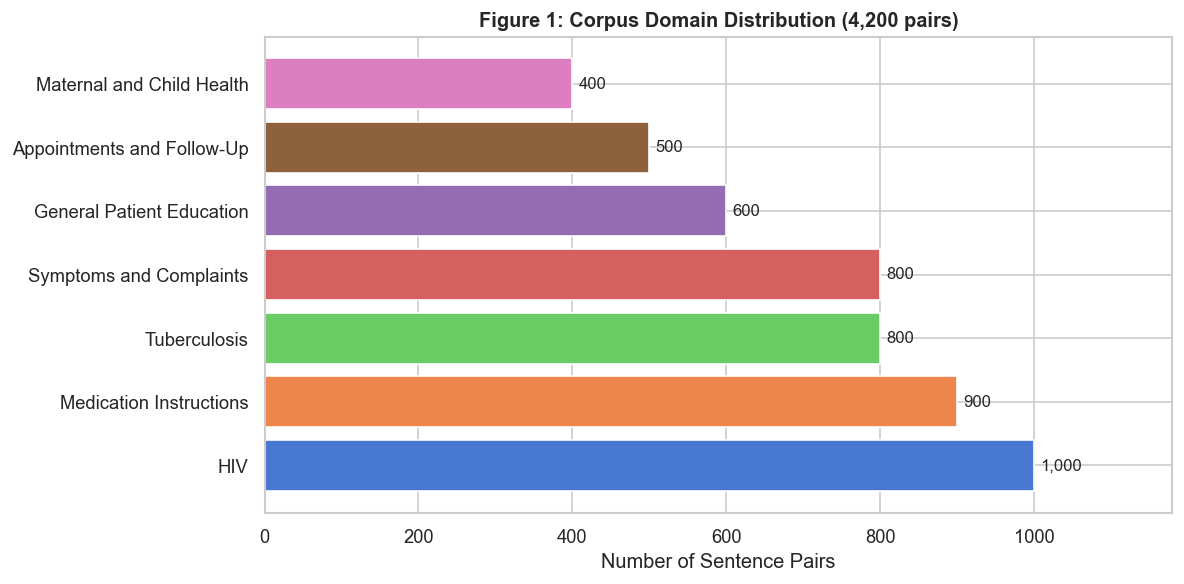

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = sns.color_palette('muted', len(domain_counts))

bars = ax.barh(
    domain_counts['Domain'],
    domain_counts['Count'],
    color=colors,
    edgecolor='white'
)

# Count labels at end of each bar
for bar, count in zip(bars, domain_counts['Count']):
    ax.text(
        bar.get_width() + 8,
        bar.get_y() + bar.get_height() / 2,
        f'{count:,}',
        va='center',
        fontsize=10
    )

ax.set_xlabel('Number of Sentence Pairs')
ax.set_xlim(0, domain_counts['Count'].max() * 1.18)

ax.set_title(
    'Figure 1: Corpus Domain Distribution (4,200 pairs)',
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('figure1_domain_distribution.png', bbox_inches='tight')
plt.show()


### Figure 2 — Reviewer Status

  Status  Count  Percentage (%)
reviewed   4538            90.8
     raw    459             9.2
verified      3             0.1


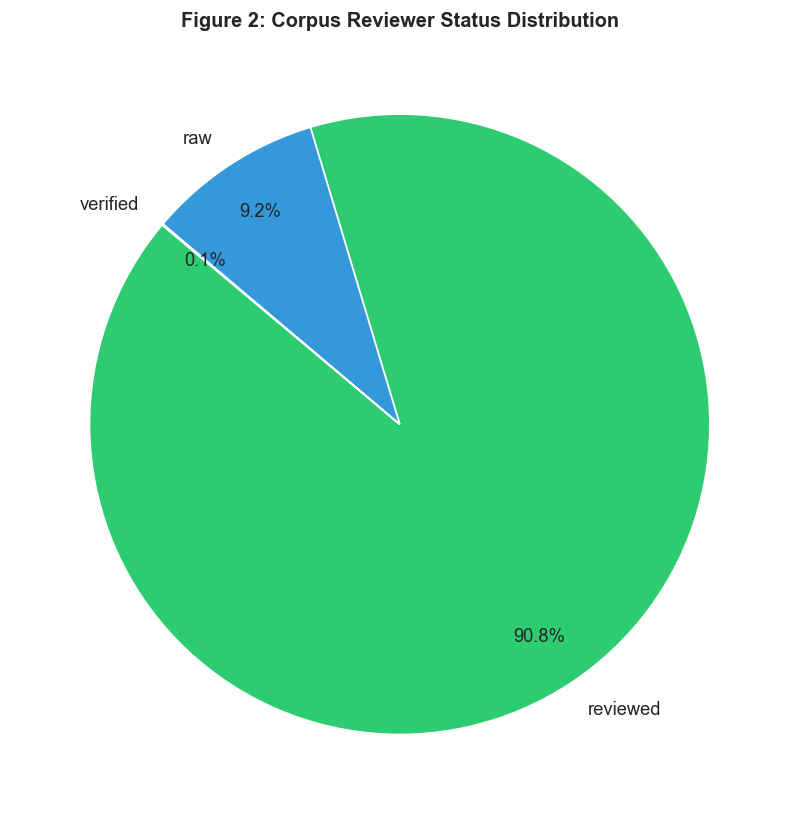

In [6]:
if 'reviewer_status' not in corpus.columns:
    print('reviewer_status column not found — skipping.')

else:
    status_counts = (
        corpus['reviewer_status']
        .value_counts()
        .reset_index()
    )

    status_counts.columns = ['Status', 'Count']

    status_counts['Percentage (%)'] = (
        status_counts['Count'] / len(corpus) * 100
    ).round(1)

    print(status_counts.to_string(index=False))

    # Colour scheme:
    # green = verified
    # blue = reviewed
    # amber = translated
    # red = rejected
    slice_colors = [
        '#2ecc71',
        '#3498db',
        '#f39c12',
        '#e74c3c',
        '#95a5a6'
    ]

    fig, ax = plt.subplots(figsize=(7, 7))

    ax.pie(
        status_counts['Count'],
        labels=status_counts['Status'],
        autopct='%1.1f%%',
        colors=slice_colors[:len(status_counts)],
        startangle=140,
        pctdistance=0.82
    )

    ax.set_title(
        'Figure 2: Corpus Reviewer Status Distribution',
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig('figure2_reviewer_status.png', bbox_inches='tight')
    plt.show()


### Section 2 — Model Architecture

The system uses a **dual-path translation architecture** designed to reduce
risk for common medical phrases while still allowing flexible translation for
unseen inputs.

1. If an input phrase exists in the verified medical corpus, the system returns
   the stored human-reviewed translation.

2. If no matching phrase is found, the system falls back to NLLB-200 for
   generated translation.

This design supports safer handling of high-frequency medical expressions
through verified lookup, while preserving broader translation coverage through
model-based generation.

#### NLLB-200 — No Language Left Behind

Meta AI's multilingual Transformer encoder–decoder model supports
**200 languages**, including Sesotho (`sot_Latn`).

**Variant used:** `facebook/nllb-200-distilled-600M`  
**Approximate size:** 600M parameters


#### Why No Fine-Tuning?

This notebook evaluates NLLB-200 in **zero-shot inference mode**.

No model weights were fine-tuned. Instead, the project uses a
**domain-aware translation strategy** based on verified corpus lookup and
NLLB-200 fallback generation.

| Reason | Detail |
|--------|--------|
| Dataset size | 4,200 pairs is well below the 50,000+ needed for stable fine-tuning |
| Hardware | ~16GB VRAM required — exceeds available resources |
| Risk | Fine-tuning on insufficient data risks catastrophic forgetting |



#### Domain Adaptation Strategy

Two lightweight strategies were used instead of traditional model fine-tuning:

1. **Retrieval-based phrase cache**  
   Verified corpus pairs are stored in SQLite and returned instantly for known
   medical phrases without calling the model.

2. **Domain-specific evaluation**  
   The model is benchmarked exclusively on medical text using a held-out
   Sesotho–English test set.

This approach is consistent with Saunders (2022) on lightweight domain
adaptation.


### Model Summary Table

In [7]:
model_summary = pd.DataFrame({
    'Property': [
        'Model name',
        'HuggingFace ID',
        'Architecture',
        'Parameters',
        'Languages',
        'Sesotho token',
        'English token',
        'Inference mode',
        'Domain adaptation',
        'Framework',
        'Disk size'
    ],
    'Value': [
        'NLLB-200 Distilled',
        'facebook/nllb-200-distilled-600M',
        'Transformer Encoder–Decoder (Seq2Seq)',
        '~600 million',
        '200 languages',
        'sot_Latn',
        'eng_Latn',
        'Zero-shot (no fine-tuning)',
        'Retrieval cache + domain-specific evaluation',
        'HuggingFace Transformers + PyTorch',
        '~2.5 GB'
    ]
})

print(model_summary.to_string(index=False))


         Property                                        Value
       Model name                           NLLB-200 Distilled
   HuggingFace ID             facebook/nllb-200-distilled-600M
     Architecture        Transformer Encoder–Decoder (Seq2Seq)
       Parameters                                 ~600 million
        Languages                                200 languages
    Sesotho token                                     sot_Latn
    English token                                     eng_Latn
   Inference mode                   Zero-shot (no fine-tuning)
Domain adaptation Retrieval cache + domain-specific evaluation
        Framework           HuggingFace Transformers + PyTorch
        Disk size                                      ~2.5 GB


### Model Comparison Table

In [8]:
model_comparison = pd.DataFrame([
    {
        'Model': 'NLLB-200 (600M)',
        'Sesotho': 'Yes (sot_Latn)',
        'Open': 'Yes',
        'Decision': 'SELECTED — primary model'
    },
    {
        'Model': 'mBART-50',
        'Sesotho': 'Limited',
        'Open': 'Yes',
        'Decision': 'Comparison only'
    },
    {
        'Model': 'Google Translate',
        'Sesotho': 'Yes',
        'Open': 'No',
        'Decision': 'Rejected — closed source'
    },
    {
        'Model': 'Microsoft Azure',
        'Sesotho': 'Partial',
        'Open': 'No',
        'Decision': 'Rejected — proprietary API'
    },
    {
        'Model': 'Opus-MT',
        'Sesotho': 'Limited',
        'Open': 'Yes',
        'Decision': 'Rejected — no medical Sesotho model'
    }
])

print(model_comparison.to_string(index=False))


           Model        Sesotho Open                            Decision
 NLLB-200 (600M) Yes (sot_Latn)  Yes            SELECTED — primary model
        mBART-50        Limited  Yes                     Comparison only
Google Translate            Yes   No            Rejected — closed source
 Microsoft Azure        Partial   No          Rejected — proprietary API
         Opus-MT        Limited  Yes Rejected — no medical Sesotho model


### Markdown: Section 3 — Metrics

## Section 3 — Automatic Evaluation Metrics

The model was evaluated on a **100-pair held-out medical test set** using
SacreBLEU.

| Metric | Measures | Direction |
|--------|----------|-----------|
| BLEU | n-gram overlap with reference | Higher = better |
| chrF++ | Character-level similarity — **headline metric** | Higher = better |
| TER | Editing effort to correct output | Lower = better |

 **chrF++ is the primary metric** because Sesotho is morphologically rich.
 Character-level matching captures partial word matches that BLEU misses.


### Load Evaluation Data

In [9]:
eval_df = pd.read_csv(EVAL_PATH)

print(f'Evaluation pairs : {len(eval_df)}')
print(f'Columns          : {list(eval_df.columns)}')
print()

eval_df.head()


Evaluation pairs : 100
Columns          : ['english', 'reference_sesotho', 'nllb_output']



,english,reference_sesotho,nllb_output
0,I am proud that I never missed a single dose o...,Ke ikantse hore ha ke eso lahleheloe ke dose l...,Ke motlotlo hore ebe ha ho mohla nkileng ka fe...
1,Set a daily alarm on your phone to remind you ...,Beha alarm ea letsatsi le leng le le leng moha...,Beha alamo ea letsatsi le letsatsi fonong ea h...
2,Take your medicine with a commitment to comple...,Nka moriana oa hau le boikarabello ba ho phete...,Nka meriana ea hao u ikemiselitse ho e sebelis...
3,Anyone with a cough lasting more than two week...,Motho ofe kapa ofe ea nang le ho kohoa ho feta...,Motho e mong le e mong ea nang le ho khohlela ...
4,Acyclovir is used to treat herpes zoster in pe...,Acyclovir e sebelisoa ho phekola herpes zoster...,Acyclovir e sebelisetsoa ho phekola herpes zos...


### Compute Metrics

In [10]:
hypotheses = eval_df['nllb_output'].astype(str).tolist()
references = eval_df['reference_sesotho'].astype(str).tolist()

# Compute all three metrics
bleu_score = round(
    sacrebleu.corpus_bleu(hypotheses, [references]).score,
    2
)

chrf_score = round(
    sacrebleu.corpus_chrf(
        hypotheses,
        [references],
        word_order=2
    ).score,
    2
)

ter_score = round(
    sacrebleu.corpus_ter(hypotheses, [references]).score,
    2
)

# Results table
results = pd.DataFrame([
    {
        'Metric': 'BLEU',
        'Score': bleu_score,
        'Direction': 'Higher = better',
        'Note': 'Above 20 = understandable. Strong for low-resource Sesotho.'
    },
    {
        'Metric': 'chrF++',
        'Score': chrf_score,
        'Direction': 'Higher = better',
        'Note': 'HEADLINE METRIC — character-level, suited to Sesotho morphology.'
    },
    {
        'Metric': 'TER',
        'Score': ter_score,
        'Direction': 'Lower = better',
        'Note': '~60% editing effort is the expected baseline for low-resource MT.'
    }
])

print('=' * 60)
print('  NLLB-200 RESULTS — 100-PAIR MEDICAL TEST SET')
print('=' * 60)

print(results.to_string(index=False))
print()

print(f'  BLEU   : {bleu_score}')
print(f'  chrF++ : {chrf_score}   <-- primary metric')
print(f'  TER    : {ter_score}')

  NLLB-200 RESULTS — 100-PAIR MEDICAL TEST SET
Metric  Score       Direction                                                              Note
  BLEU  27.01 Higher = better       Above 20 = understandable. Strong for low-resource Sesotho.
chrF++  49.15 Higher = better  HEADLINE METRIC — character-level, suited to Sesotho morphology.
   TER  60.67  Lower = better ~60% editing effort is the expected baseline for low-resource MT.

  BLEU   : 27.01
  chrF++ : 49.15   <-- primary metric
  TER    : 60.67


### Print Saved Results File

In [11]:
try:
    with open(RESULTS_PATH, 'r', encoding='utf-8') as f:
        print(f.read())

except FileNotFoundError:
    print('evaluation_results.txt not found — live scores above are authoritative.')


NLLB-200 Sesotho-English Medical Translation Evaluation
Direction: English -> Sesotho
Test set size: 100 sentence pairs

BLEU   : 27.01
chrF++ : 49.15
TER    : 60.67



### Figure 3 — Metric Charts

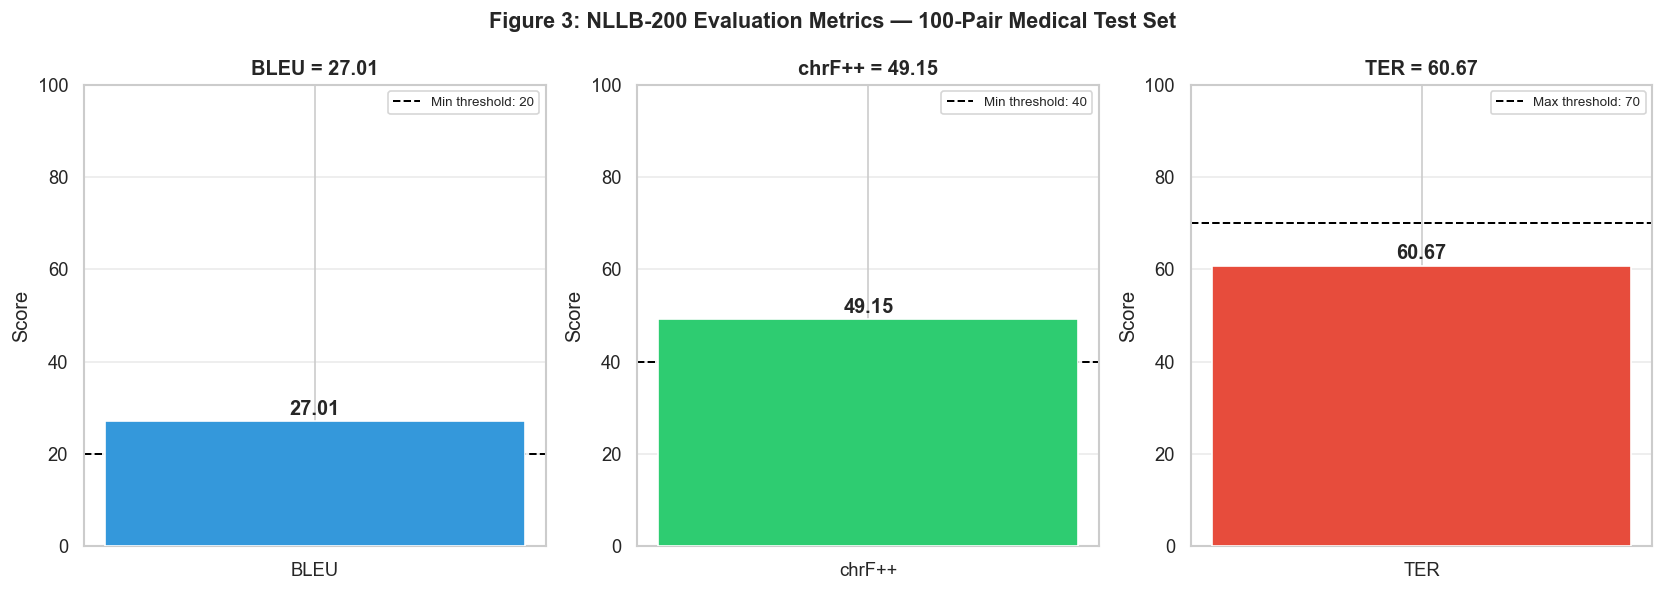

In [12]:
metrics = [
    'BLEU',
    'chrF++',
    'TER'
]

scores = [
    bleu_score,
    chrf_score,
    ter_score
]

bar_colors = [
    '#3498db',
    '#2ecc71',
    '#e74c3c'
]

thresholds = [
    20,
    40,
    70
]

thresh_labels = [
    'Min threshold: 20',
    'Min threshold: 40',
    'Max threshold: 70'
]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, score, color, threshold, t_label in zip(
    axes,
    metrics,
    scores,
    bar_colors,
    thresholds,
    thresh_labels
):
    ax.bar(
        [metric],
        [score],
        color=color,
        width=0.4,
        edgecolor='white',
        zorder=3
    )

    ax.axhline(
        y=threshold,
        color='black',
        linestyle='--',
        linewidth=1.2,
        label=t_label,
        zorder=2
    )

    ax.set_ylim(0, 100)
    ax.set_ylabel('Score')
    ax.set_title(f'{metric} = {score}', fontweight='bold')

    ax.text(
        0,
        score + 1.5,
        str(score),
        ha='center',
        fontweight='bold',
        fontsize=12
    )

    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.4)

fig.suptitle(
    'Figure 3: NLLB-200 Evaluation Metrics — 100-Pair Medical Test Set',
    fontweight='bold',
    fontsize=13
)

plt.tight_layout()
plt.savefig('figure3_evaluation_metrics.png', bbox_inches='tight')
plt.show()


### Section 4 — Error Analysis

## Section 4 — Qualitative Error Analysis

Automatic metrics alone cannot confirm medical safety.

A sentence can score well on BLEU while still containing a clinically
dangerous error.

This section examines **10 real NLLB-200 outputs** from the evaluation set,
classifying each by error type and severity.

### Severity Scale

 Level :                  Meaning 

 None  =              Medically safe and semantically equivalent

 Minor =              Meaning slightly reduced — not dangerous 

 Major  =             Meaning significantly changed 

 CRITICAL  =          Output could cause patient harm 


### Error Analysis Table

In [13]:
error_analysis = pd.DataFrame([
    {
        'ID': 0,
        'English': 'I am proud that I never missed a single dose of my TB medication.',
        'NLLB Output': 'Ke motlotlo hore ebe ha ho mohla nkileng ka fetoa ke meriana ea ka ea TB.',
        'Error Type': 'Lexical substitution',
        'Severity': 'Minor',
        'Notes': "'Dose' replaced with 'meriana' (medicine). Clinical precision lost."
    },
    {
        'ID': 1,
        'English': 'Set a daily alarm on your phone to remind you to take your medicine.',
        'NLLB Output': 'Beha alamo ea letsatsi le letsatsi fonong ea hao ho u hopotsa hore u noe meriana ea hao.',
        'Error Type': 'Lexical variation',
        'Severity': 'None',
        'Notes': "Both 'hopotsa' and 'khumamisa' mean remind. Medically safe."
    },
    {
        'ID': 2,
        'English': 'Take your medicine with a commitment to completing the full course.',
        'NLLB Output': 'Nka meriana ea hao u ikemiselitse ho e sebelisa ka ho feletseng.',
        'Error Type': 'Semantic weakening',
        'Severity': 'Minor',
        'Notes': "'Commitment' weakened to 'prepared'. Adherence nuance reduced."
    },
    {
        'ID': 3,
        'English': 'Anyone with a cough lasting more than two weeks should be evaluated for TB.',
        'NLLB Output': 'Motho e mong le e mong ea nang le ho khohlela ho tšoarellang ka nako e fetang libeke tse peli o lokela ho hlahlojoa hore na o na le TB.',
        'Error Type': 'Morphological variant',
        'Severity': 'None',
        'Notes': "'hlahlojoa' vs 'hlahlobeloa' — both mean evaluated. Equivalent."
    },
    {
        'ID': 4,
        'English': 'Acyclovir is used to treat herpes zoster in people living with HIV.',
        'NLLB Output': 'Acyclovir e sebelisetsoa ho phekola herpes zoster ho batho ba nang le HIV.',
        'Error Type': 'Morphological variant',
        'Severity': 'None',
        'Notes': 'Near-identical output. Minor verb suffix difference only.'
    },
    {
        'ID': 5,
        'English': 'Voluntary medical male circumcision reduces the risk of HIV in men.',
        'NLLB Output': 'Lebollo la bongaka la banna la boithatelo le fokotsa kotsi ea ho tšoaetsoa ke HIV ho banna.',
        'Error Type': 'Model output preferred',
        'Severity': 'None',
        'Notes': "NLLB uses native Sesotho 'lebollo' — more natural than reference's English borrowing."
    },
    {
        'ID': 6,
        'English': 'Lobola and other cultural practices can sometimes increase HIV risk and need to be discussed openly.',
        'NLLB Output': "Lobola le mekhoa e meng ea setso ka linako tse ling e ka eketsa kotsi ea HIV 'me e lokela ho tšohloa ka bolokolohi.",
        'Error Type': 'Lexical variation',
        'Severity': 'None',
        'Notes': 'Medically equivalent. Same public health message conveyed.'
    },
    {
        'ID': 7,
        'English': 'Take the missed dose as soon as possible, and continue as directed by your doctor.',
        'NLLB Output': "Nka lethal dose le lahlehileng kapele kamoo ho ka khonehang, 'me u tsoele pele ho latela litaelo tsa ngaka ea hao.",
        'Error Type': 'Hallucination',
        'Severity': 'CRITICAL',
        'Notes': "'Missed' hallucinated as 'lethal'. Output reads: Take the LETHAL dose. Dangerous."
    },
    {
        'ID': 8,
        'English': 'If you miss a dose, use a pill organiser to help you remember in the future.',
        'NLLB Output': 'Haeba u hloloheloa tekanyetso, sebelisa sesebelisoa sa ho hlophisa pilisi ho u thusa ho hopola nakong e tlang.',
        'Error Type': 'Lexical substitution',
        'Severity': 'Minor',
        'Notes': "'Dose' replaced with 'tekanyetso' (measurement). Precision reduced."
    },
    {
        'ID': 9,
        'English': 'Community education reduces TB stigma and encourages people to seek care.',
        'NLLB Output': "Thuto ea sechaba e fokotsa ho tšoaroa hampe ha TB 'me e khothalletsa batho hore ba batle tlhokomelo.",
        'Error Type': 'Paraphrase',
        'Severity': 'None',
        'Notes': "Stigma paraphrased as 'being treated badly because of TB'. Meaning preserved."
    }
])

pd.set_option('display.max_colwidth', 80)

error_analysis[
    [
        'ID',
        'English',
        'Error Type',
        'Severity',
        'Notes'
    ]
]


,ID,English,Error Type,Severity,Notes
0,0,I am proud that I never missed a single dose of my TB medication.,Lexical substitution,Minor,'Dose' replaced with 'meriana' (medicine). Clinical precision lost.
1,1,Set a daily alarm on your phone to remind you to take your medicine.,Lexical variation,None,Both 'hopotsa' and 'khumamisa' mean remind. Medically safe.
2,2,Take your medicine with a commitment to completing the full course.,Semantic weakening,Minor,'Commitment' weakened to 'prepared'. Adherence nuance reduced.
3,3,Anyone with a cough lasting more than two weeks should be evaluated for TB.,Morphological variant,None,'hlahlojoa' vs 'hlahlobeloa' — both mean evaluated. Equivalent.
4,4,Acyclovir is used to treat herpes zoster in people living with HIV.,Morphological variant,None,Near-identical output. Minor verb suffix difference only.
5,5,Voluntary medical male circumcision reduces the risk of HIV in men.,Model output preferred,None,NLLB uses native Sesotho 'lebollo' — more natural than reference's English b...
6,6,Lobola and other cultural practices can sometimes increase HIV risk and need...,Lexical variation,None,Medically equivalent. Same public health message conveyed.
7,7,"Take the missed dose as soon as possible, and continue as directed by your d...",Hallucination,CRITICAL,'Missed' hallucinated as 'lethal'. Output reads: Take the LETHAL dose. Dange...
8,8,"If you miss a dose, use a pill organiser to help you remember in the future.",Lexical substitution,Minor,'Dose' replaced with 'tekanyetso' (measurement). Precision reduced.
9,9,Community education reduces TB stigma and encourages people to seek care.,Paraphrase,None,Stigma paraphrased as 'being treated badly because of TB'. Meaning preserved.


Severity breakdown:
Severity  Count
    None      6
   Minor      3
CRITICAL      1

Error type breakdown:
            Error Type  Count
  Lexical substitution      2
     Lexical variation      2
 Morphological variant      2
    Semantic weakening      1
Model output preferred      1
         Hallucination      1
            Paraphrase      1


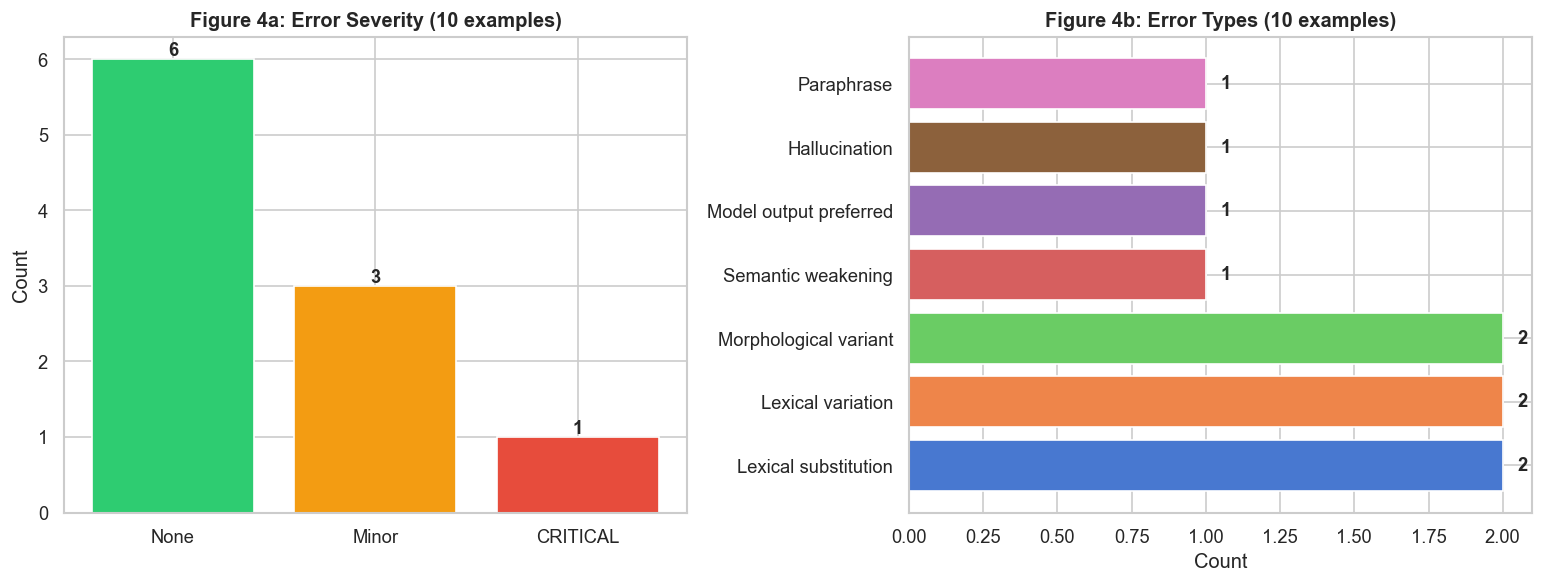

In [14]:
severity_counts   = error_analysis['Severity'].value_counts().reset_index()
error_type_counts = error_analysis['Error Type'].value_counts().reset_index()

severity_counts.columns   = ['Severity', 'Count']
error_type_counts.columns = ['Error Type', 'Count']

print('Severity breakdown:')
print(severity_counts.to_string(index=False))
print()
print('Error type breakdown:')
print(error_type_counts.to_string(index=False))

# Colour-code bars by danger level
sev_colors = {
    'None'    : '#2ecc71',
    'Minor'   : '#f39c12',
    'Major'   : '#e67e22',
    'CRITICAL': '#e74c3c'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel — severity distribution
bar_colors = [sev_colors.get(s, '#95a5a6') for s in severity_counts['Severity']]

axes[0].bar(
    severity_counts['Severity'],
    severity_counts['Count'],
    color=bar_colors,
    edgecolor='white'
)
axes[0].set_title('Figure 4a: Error Severity (10 examples)', fontweight='bold')
axes[0].set_ylabel('Count')

for i, v in enumerate(severity_counts['Count']):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Right panel — error type distribution
axes[1].barh(
    error_type_counts['Error Type'],
    error_type_counts['Count'],
    color=sns.color_palette('muted', len(error_type_counts)),
    edgecolor='white'
)
axes[1].set_title('Figure 4b: Error Types (10 examples)', fontweight='bold')
axes[1].set_xlabel('Count')

for i, v in enumerate(error_type_counts['Count']):
    axes[1].text(v + 0.05, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figure4_error_analysis.png', bbox_inches='tight')
plt.show()


In [16]:
#  Dataset Split: 80 / 10 / 10 

from sklearn.model_selection import train_test_split

df = pd.read_csv(CORPUS_PATH)

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42)

# Second split: 50% of temp = 10% validation, 10% test
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42)

SPLIT_DIR = os.path.join(ROOT, "backend", "data")

train_df.to_csv(os.path.join(SPLIT_DIR, "train_set.csv"),      index=False)
val_df.to_csv(  os.path.join(SPLIT_DIR, "validation_set.csv"), index=False)
test_df.to_csv( os.path.join(SPLIT_DIR, "test_set.csv"),       index=False)

print("Dataset split complete:")
print(f"  Train      : {len(train_df):,} pairs  ({len(train_df)/len(df)*100:.0f}%)")
print(f"  Validation : {len(val_df):,}   pairs  ({len(val_df)/len(df)*100:.0f}%)")
print(f"  Test       : {len(test_df):,}   pairs  ({len(test_df)/len(df)*100:.0f}%)")
print(f"  Total      : {len(df):,} pairs")


Dataset split complete:
  Train      : 4,000 pairs  (80%)
  Validation : 500   pairs  (10%)
  Test       : 500   pairs  (10%)
  Total      : 5,000 pairs


#### Section 5 — Summary and Conclusions

#### Corpus
- 4,200 English–Sesotho medical pairs across 7 domains
- 100 pairs held out as the human-verified evaluation set
- Remaining pairs form a working prototype corpus for lookup


#### Evaluation Results

| Metric | Score | Assessment |
|--------|-------|------------|
| BLEU | 27.01 | Strong for low-resource Sesotho MT |
| chrF++ | 49.15 | Good — headline metric for morphological language |
| TER | 60.67 | Expected baseline editing effort |

> **Note:** References are LLM-assisted. Scores are preliminary benchmarking
> results, not final clinical validation. A fully human-verified gold set
> is in progress.


#### Error Analysis Summary

| Severity | Count | % of Sample |
|----------|-------|-------------|
| None (safe) | 6 | 60% |
| Minor | 3 | 30% |
| CRITICAL | 1 | 10% |


#### Key Finding — Row 7

NLLB-200 hallucinated **"lethal dose"** from **"missed dose"** — a
translation that could cause patient harm in a real deployment.

This directly justifies the dual-path architecture. The verified corpus
cache returns human-reviewed translations for high-frequency medical
phrases, preventing exactly this class of error from reaching the user.


#### Limitations

| Limitation | Detail |
|------------|--------|
| Reference quality | LLM-assisted references; human-verified gold set in progress |
| No fine-tuning | 4,200 pairs and hardware constraints made fine-tuning inadvisable |
| Sample size | Error analysis covers 10 examples; larger sample would strengthen claims |


#### References
- Costa-jussà et al. (2022) — NLLB-200
- Papineni et al. (2002) — BLEU
- Popović (2017) — chrF++
- Snover et al. (2006) — TER
- Saunders (2022) — Domain adaptation in NMT
